## Import Libraries

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../scripts')
from data_preprocessing import *

#### Load Data

In [2]:
# Set up input and output paths
RAW_DATA_DIR = '../data/raw'
PROCESSED_DATA_DIR = '../data/processed'

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# Load raw data
movies_file = os.path.join(RAW_DATA_DIR, 'movies_metadata.csv')
ratings_file = os.path.join(RAW_DATA_DIR, 'ratings_small.csv')

movies = pd.read_csv(movies_file)
ratings = pd.read_csv(ratings_file)

display(movies.head())
display(ratings.head())

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


#### Data Parsing and processing

In [3]:
movies['genres'] = movies['genres'].apply(parse_genres)

In [4]:
process_data(movies, ratings)

movies.to_csv("../data/processed/movies_clean.csv", index=False)
ratings.to_csv("../data/processed/ratings_clean.csv", index=False)
display(movies)
display(ratings)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,release_year,bert_text
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[Animation, Comedy, Family]",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,Led by Woody Andys toys live happily in his ro...,...,81.0,[English],Released,nan,Toy Story,False,7.7,5415.0,1995,"[TITLE]Toy Story[YEAR]1995[GENRES]Animation,Co..."
1,False,NaN,65000000,"[Adventure, Fantasy, Family]",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,104.0,"[English, Français]",Released,Roll the dice and unleash the excitement,Jumanji,False,6.9,2413.0,1995,"[TITLE]Jumanji[YEAR]1995[GENRES]Adventure,Fant..."
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[Romance, Comedy]",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,101.0,[English],Released,Still Yelling Still Fighting Still Ready for Love,Grumpier Old Men,False,6.5,92.0,1995,[TITLE]Grumpier Old Men[YEAR]1995[GENRES]Roman...
3,False,NaN,16000000,"[Comedy, Drama, Romance]",NaN,31357,tt0114885,en,Waiting to Exhale,Cheated on mistreated and stepped on the women...,...,127.0,[English],Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,1995,[TITLE]Waiting to Exhale[YEAR]1995[GENRES]Come...
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,[Comedy],NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,106.0,[English],Released,Just When His World Is Back To Normal Hes In F...,Father of the Bride Part II,False,5.7,173.0,1995,[TITLE]Father of the Bride Part II[YEAR]1995[G...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45461,False,NaN,0,"[Drama, Family]",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman,...,90.0,[فارسی],Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0,0,"[TITLE]Subdue[YEAR]0[GENRES]Drama,Family[OVERV..."
45462,False,NaN,0,[Drama],NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,360.0,[],Released,nan,Century of Birthing,False,9.0,3.0,2011,[TITLE]Century of Birthing[YEAR]2011[GENRES]Dr...
45463,False,NaN,0,"[Action, Drama, Thriller]",NaN,67758,tt0303758,en,Betrayal,When one of her hits goes wrong a professional...,...,90.0,[English],Released,A deadly game of wits,Betrayal,False,3.8,6.0,2003,"[TITLE]Betrayal[YEAR]2003[GENRES]Action,Drama,..."
45464,False,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,In a small town live two brothers one a minist...,...,87.0,[],Released,nan,Satan Triumphant,False,0.0,0.0,1917,[TITLE]Satan Triumphant[YEAR]1917[GENRES][OVER...


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205
...,...,...,...,...
99999,671,6268,2.5,1065579370
100000,671,6269,4.0,1065149201
100001,671,6365,4.0,1070940363
100002,671,6385,2.5,1070979663


## EDA Visualizations

#### 1. Distribution of release years

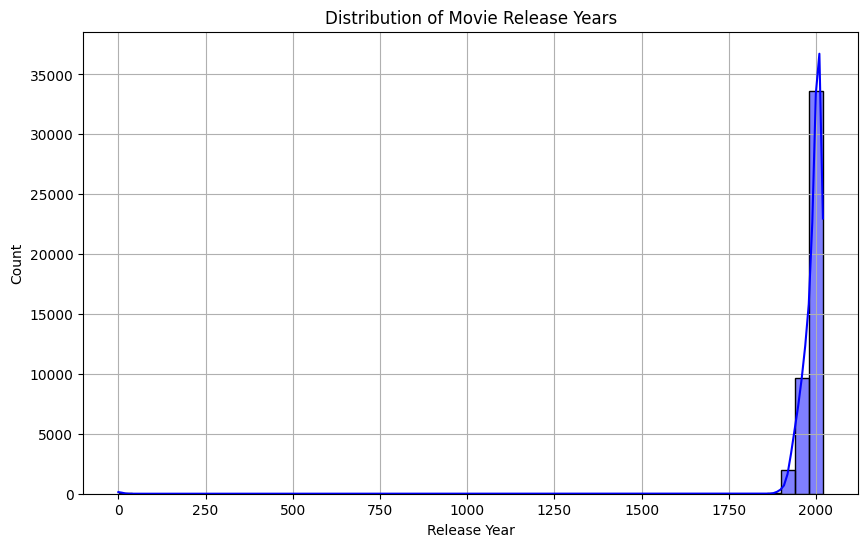

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(movies['release_year'].dropna(), bins=50, kde=True, color='blue')
plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 2. Top 10 most common genres

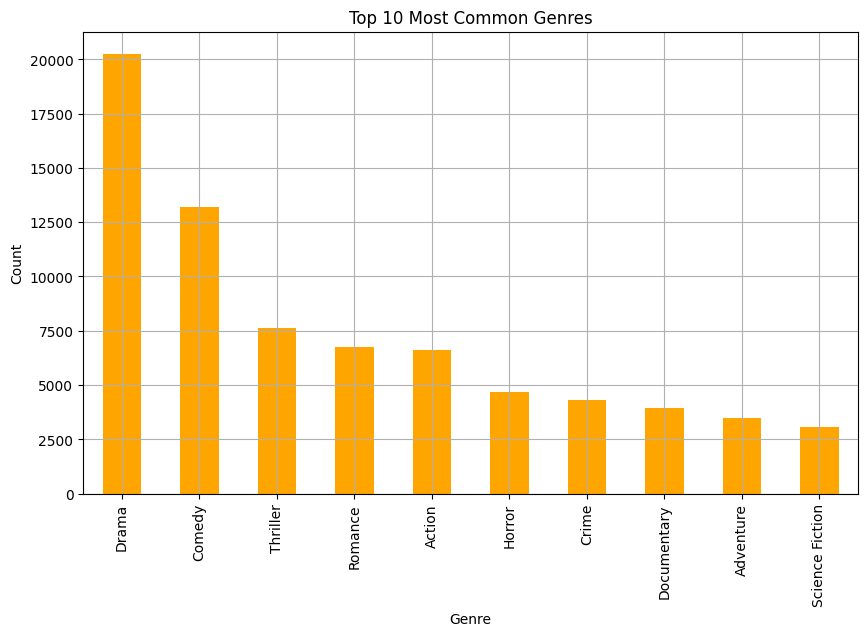

In [6]:
# Calculate genre counts
genre_counts = pd.Series([genre for genres_list in movies['genres'] for genre in genres_list]).value_counts()

# Plot the top 10 most common genres
plt.figure(figsize=(10, 6))
genre_counts.head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 3. Distribution of movie popularity

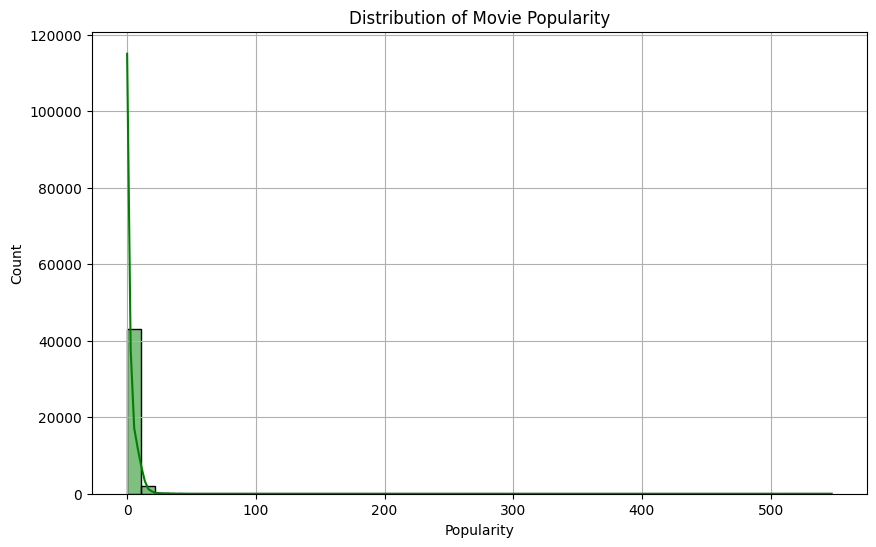

In [7]:

# Convert 'popularity' column to numeric, coercing errors to NaN
movies['popularity'] = pd.to_numeric(movies['popularity'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.histplot(movies['popularity'].dropna(), bins=50, kde=True, color='green')
plt.title('Distribution of Movie Popularity')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 4. Distribution of vote averages

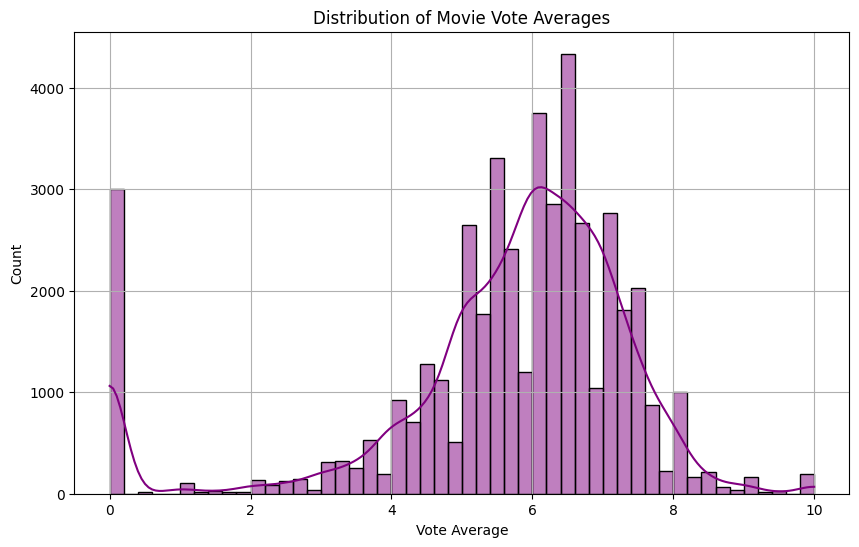

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(movies['vote_average'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Movie Vote Averages')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 5. Ratings distribution

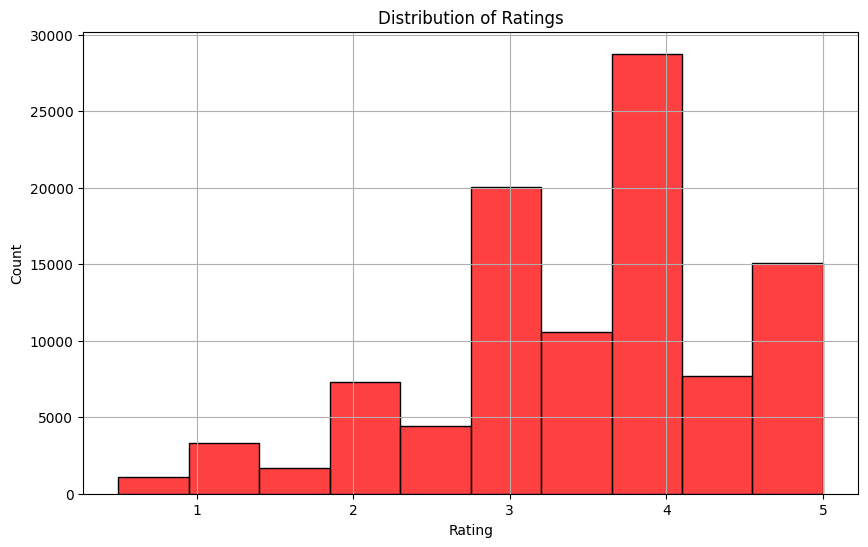

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings['rating'], bins=10, kde=False, color='red')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid()
plt.show()

#### 6. Number of ratings per movie (Top 10 most rated movies)

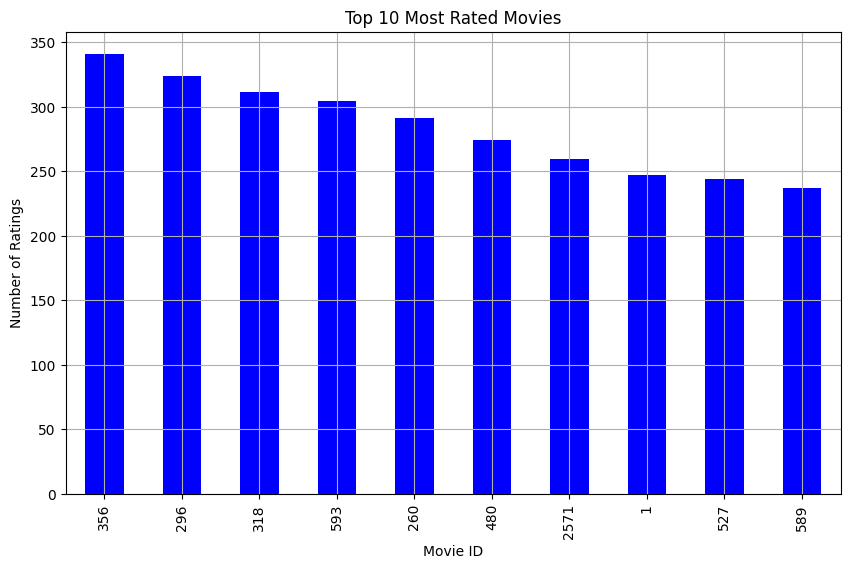

In [10]:
ratings_count = ratings.groupby('movieId').size().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ratings_count.head(10).plot(kind='bar', color='blue')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Movie ID')
plt.ylabel('Number of Ratings')
plt.grid()
plt.show()

#### 7. Average rating per movie

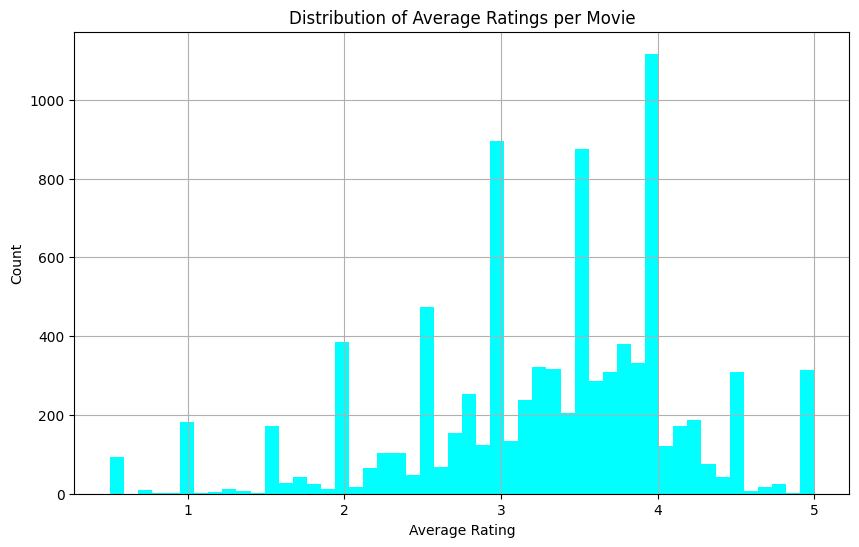

In [11]:
average_ratings = ratings.groupby('movieId')['rating'].mean()
plt.figure(figsize=(10, 6))
average_ratings.plot(kind='hist', bins=50, color='cyan')
plt.title('Distribution of Average Ratings per Movie')
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.grid()
plt.show()